In [1]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch.optim as optim
import onnxruntime

from sklearn.linear_model import LinearRegression
from scipy.ndimage import gaussian_filter1d
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Configuration
BATCH_SIZE = 32

CIRCUIT_LIST = [
    "simple_circuit",
    "montreal_circuit",
    "montmelo_circuit",
    "nurburgring_circuit"
]

LEARNING_RATE = 1e-4

IMAGE_SHAPE = (3, 240, 640)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using DEVICE: {DEVICE}")

Using DEVICE: cuda


In [3]:
IS_BALANCED = True
CSE_FILE_NAME = ""
VERSION = 'v3.2'
if IS_BALANCED:
    CSV_FILE_NAME = f"balanced_train_{VERSION}.csv"
else: 
    CSV_FILE_NAME = "train.csv"
    
OUTPUT_DIR = ""

# make sure output_dir exist
os.makedirs(OUTPUT_DIR,exist_ok=True)

## CNN CLASSES

In [4]:
class FollowLineDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        # Optional: Validate required columns
        expected_columns = ['image', 'v', 'w']
        if len(self.annotations.columns) < 3:
            raise ValueError(f"CSV must have at least 3 columns: {expected_columns}")
        
    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.item()  # support Tensor indices
    
        # Get image name and velocity values
        img_name = self.annotations.iloc[idx, 0]
        linear_velocity = float(self.annotations.iloc[idx, 1])
        angular_velocity = float(self.annotations.iloc[idx, 2])
    
        # Optional: round to desired precision (e.g., 3 decimal places)
        linear_velocity = round(linear_velocity, 3)
        angular_velocity = round(angular_velocity, 3)
    
        # Load image
        img_path = os.path.join(self.root_dir, img_name)
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            raise FileNotFoundError(f"Image not found: {img_path}")
    
        if self.transform:
            image = self.transform(image)
    
        velocities = torch.tensor([linear_velocity, angular_velocity], dtype=torch.float32)
        return image, velocities

In [5]:
class PilotNet(nn.Module):
    def __init__(self):
        super(PilotNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(24, 36, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(36, 48, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(48, 64, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3),
            nn.ReLU()
        )
        # Dynamically calculate flattened feature size
        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, 240, 640)
            dummy_output = self.features(dummy_input)
            self.flattened_size = dummy_output.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Linear(self.flattened_size, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
            nn.ReLU(),
            nn.Linear(10, 2)  # Output: [v, w]
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


# with drop
class PilotNet2(nn.Module):
    def __init__(self):
        super(PilotNet, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=5, stride=2),
            nn.ReLU(),

            nn.Conv2d(24, 36, kernel_size=5, stride=2),
            nn.BatchNorm2d(36),
            nn.ReLU(),

            nn.Conv2d(36, 48, kernel_size=5, stride=2),
            nn.BatchNorm2d(48),
            nn.ReLU(),

            nn.Conv2d(48, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # Dynamically compute the flattened feature size
        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, 240, 640)
            dummy_output = self.features(dummy_input)
            self.flattened_size = dummy_output.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Linear(self.flattened_size, 100),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(50, 10),
            nn.ReLU(),

            nn.Linear(10, 2)  # Output: [v, w] (or change to 1 if only predicting steering angle)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


## loop through all circuits

############################### montreal_circuit #############################################################


Epoch 1/10 [Test]: 100%|██████████████████████| 226/226 [01:21<00:00,  2.76it/s]


Epoch 1: Train Loss = 1.2563, Test Loss = 1.3359


Epoch 2/10 [Test]: 100%|██████████████████████| 226/226 [01:17<00:00,  2.92it/s]


Epoch 2: Train Loss = 0.1403, Test Loss = 0.8591


...

Epoch 9: Train Loss = 0.0547, Test Loss = 0.3909


Epoch 10/10 [Test]: 100%|█████████████████████| 226/226 [01:18<00:00,  2.89it/s]


Epoch 10: Train Loss = 0.0523, Test Loss = 0.2781


Evaluating: 100%|█████████████████████████████| 226/226 [01:18<00:00,  2.87it/s]


Elapsed time: 2466.8411 seconds


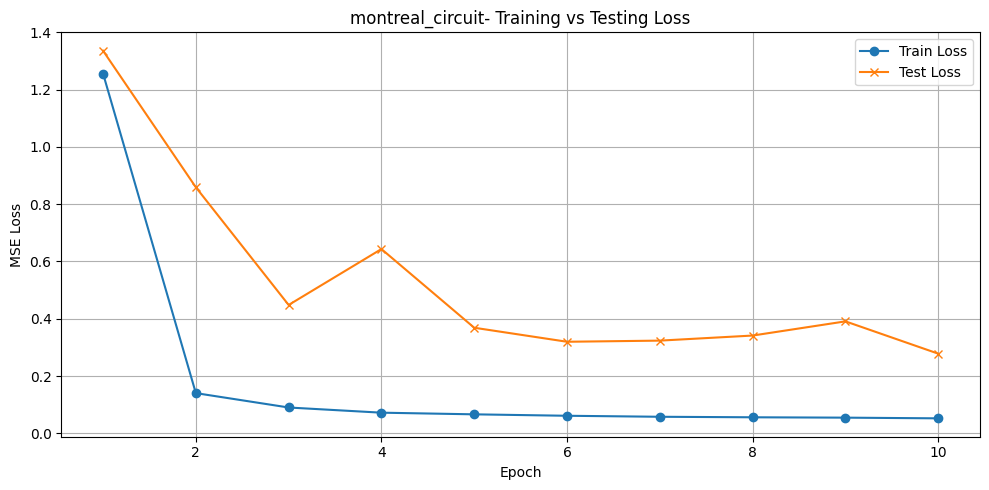

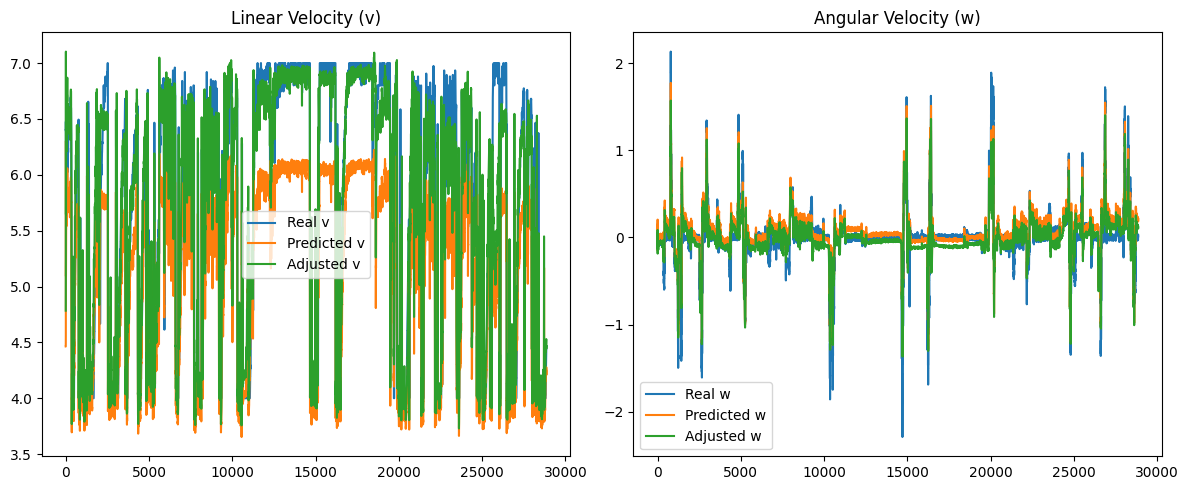

In [6]:
import time
start_time = time.time()

NUM_EPOCHS = 10
TMP_CIRCUIT_LIST = CIRCUIT_LIST = [
    # "simple_circuit",
    # "nurburgring_circuit",
    # "montmelo_circuit",
    "montreal_circuit" 
]
CIRCUIT_EPOCH_NUMBERS = {
    "simple_circuit":8,
    "montmelo_circuit":8, 
    "nurburgring_circuit":3,
    "montreal_circuit":5 
}

for circuit in TMP_CIRCUIT_LIST:
    # get test circtuit
    TEST_CIRCUIT = circuit
    
    # get input file according test circuit
    INPUT_BASE_DIR = ""
    # CREATE OUTPUT DIR
    os.makedirs(os.path.join(OUTPUT_DIR,TEST_CIRCUIT),exist_ok=True)
    # continue

    # TRANSFORM AND LOAD DATASET
    transform = transforms.Compose([
        transforms.Resize((240, 640)),
        transforms.ToTensor(),
    ])
    
    train_dataset = FollowLineDataset(os.path.join(INPUT_BASE_DIR,CSV_FILE_NAME),os.path.join(INPUT_BASE_DIR,'train'), transform=transform)
    test_dataset = FollowLineDataset(os.path.join(INPUT_BASE_DIR,"test.csv"), os.path.join(INPUT_BASE_DIR,'test'), transform=transform)
    
    
    train_size = len(train_dataset)
    test_size = len(test_dataset)
    
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


    # INTIALIZE MODEL AND ADD OPTIMIZER
    model = PilotNet().to(DEVICE)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    ############################### TRAIN AND TEST #############################################################
    print(f"############################### {TEST_CIRCUIT} #############################################################")
    train_losses = []
    test_losses = []
    # Training + Validation loop
    # NUM_EPOCHS = CIRCUIT_EPOCH_NUMBERS[TEST_CIRCUIT]
    for epoch in range(NUM_EPOCHS):
        model.train()
        total_train_loss = 0.0
        for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item() * images.size(0)
        
        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)
    
        model.eval()
        total_test_loss = 0.0
        with torch.no_grad():
            for images, targets in tqdm(test_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Test]"):
                images, targets = images.to(DEVICE), targets.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, targets)
                total_test_loss += loss.item() * images.size(0)
    
        avg_test_loss = total_test_loss / len(test_loader.dataset)
        test_losses.append(avg_test_loss)
    
        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}")

        

    ######################################## SAVE MODEL ###################################################
    dummy_input = torch.randn(1, 3, 240, 640).to(DEVICE)
    onnx_path = f"{OUTPUT_DIR}/{TEST_CIRCUIT}/pilotnet_test_v1-{TEST_CIRCUIT}-balanced_{VERSION}.onnx"
    torch.onnx.export(model, dummy_input, onnx_path,
                      input_names=['input'], output_names=['output'],
                      dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
                      opset_version=11)


    ################################## PLOTTING TEST-TRAIN LOSS CURVE ###########################################
    # Plotting loss curve
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, NUM_EPOCHS + 1), train_losses[:NUM_EPOCHS], label='Train Loss', marker='o')
    plt.plot(range(1, NUM_EPOCHS + 1), test_losses[:NUM_EPOCHS], label=f"Test Loss", marker='x')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(f'{TEST_CIRCUIT}- Training vs Testing Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{TEST_CIRCUIT}/{TEST_CIRCUIT}-{VERSION}-loss_curve.png")
    # plt.show() 


    ############################################# EVALUATION MATRICES ######################################################
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc="Evaluating"):
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs = model(images)
            all_preds.append(outputs.cpu())
            all_targets.append(targets.cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    mse_total = mean_squared_error(all_targets, all_preds)
    mae_total = mean_absolute_error(all_targets, all_preds)
    r2_total = r2_score(all_targets, all_preds)
    
    mse_v = mean_squared_error(all_targets[:, 0], all_preds[:, 0])
    mae_v = mean_absolute_error(all_targets[:, 0], all_preds[:, 0])
    r2_v = r2_score(all_targets[:, 0], all_preds[:, 0])
    
    mse_w = mean_squared_error(all_targets[:, 1], all_preds[:, 1])
    mae_w = mean_absolute_error(all_targets[:, 1], all_preds[:, 1])
    r2_w = r2_score(all_targets[:, 1], all_preds[:, 1])


    # save evaluation matrics results
    with open(f"{OUTPUT_DIR}/{TEST_CIRCUIT}/evaluation_matrics-{VERSION}.txt", "w") as f:
        f.write(f"\n################## {TEST_CIRCUIT} ##################\n")
        f.write(f"--- Evaluation Metrics ---\n")
        f.write(f"Combined - MSE: {mse_total:.4f}, MAE: {mae_total:.4f}, R2: {r2_total:.4f}\n")
        f.write(f"Linear Velocity (v) - MSE: {mse_v:.4f}, MAE: {mae_v:.4f}, R2: {r2_v:.4f}\n")
        f.write(f"Angular Velocity (w) - MSE: {mse_w:.4f}, MAE: {mae_w:.4f}, R2: {r2_w:.4f}\n")
        f.write(f"\n\n\n")




    ############################################# Post-processing ######################################################
    # Rescale v
    v_scaler = LinearRegression()
    v_scaler.fit(all_preds[:, 0].reshape(-1, 1), all_targets[:, 0])
    adjusted_v = v_scaler.predict(all_preds[:, 0].reshape(-1, 1))
    
    # Rescale w
    w_scaler = LinearRegression()
    w_scaler.fit(all_preds[:, 1].reshape(-1, 1), all_targets[:, 1])
    adjusted_w = w_scaler.predict(all_preds[:, 1].reshape(-1, 1))
    
    # Smoothing using Gaussian filter
    smoothed_v = gaussian_filter1d(adjusted_v, sigma=1)
    smoothed_w = gaussian_filter1d(adjusted_w, sigma=1)
    
    # Combine final outputs
    final_outputs = np.stack([smoothed_v, smoothed_w], axis=1)
    
    # ------------------ Final Metrics After Post-Processing ------------------
    
    mse_total_adj = mean_squared_error(all_targets, final_outputs)
    mae_total_adj = mean_absolute_error(all_targets, final_outputs)
    r2_total_adj = r2_score(all_targets, final_outputs)
    
    mse_v_adj = mean_squared_error(all_targets[:, 0], final_outputs[:, 0])
    mae_v_adj = mean_absolute_error(all_targets[:, 0], final_outputs[:, 0])
    r2_v_adj = r2_score(all_targets[:, 0], final_outputs[:, 0])
    
    mse_w_adj = mean_squared_error(all_targets[:, 1], final_outputs[:, 1])
    mae_w_adj = mean_absolute_error(all_targets[:, 1], final_outputs[:, 1])
    r2_w_adj = r2_score(all_targets[:, 1], final_outputs[:, 1])


    # save evaluation matrics results
    with open(f"{OUTPUT_DIR}/{TEST_CIRCUIT}/evaluation_matrics_rescaling_smooting-{VERSION}.txt", "w") as f:
        f.write(f"\n################## {TEST_CIRCUIT} ##################\n")
        f.write("--- Evaluation Metrics After Rescaling + Smoothing ---\n")
        f.write(f"Combined - MSE: {mse_total_adj:.4f}, MAE: {mae_total_adj:.4f}, R2: {r2_total_adj:.4f}\n")
        f.write(f"Linear Velocity (v) - MSE: {mse_v_adj:.4f}, MAE: {mae_v_adj:.4f}, R2: {r2_v_adj:.4f}\n")
        f.write(f"Angular Velocity (w) - MSE: {mse_w_adj:.4f}, MAE: {mae_w_adj:.4f}, R2: {r2_w_adj:.4f}\n")
        f.write(f"\n\n\n")
        
    
    # Optional: Save final output
    np.save(os.path.join(OUTPUT_DIR,TEST_CIRCUIT, f"{TEST_CIRCUIT}_final_predictions.npy"), final_outputs)


    # plot the smooting and adjustment

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(all_targets[:, 0], label="Real v")
    plt.plot(all_preds[:, 0], label="Predicted v")
    plt.plot(final_outputs[:, 0], label="Adjusted v")
    plt.legend()
    plt.title("Linear Velocity (v)")
    
    plt.subplot(1, 2, 2)
    plt.plot(all_targets[:, 1], label="Real w")
    plt.plot(all_preds[:, 1], label="Predicted w")
    plt.plot(final_outputs[:, 1], label="Adjusted w")
    plt.legend()
    plt.title("Angular Velocity (w)")
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,TEST_CIRCUIT,f"{TEST_CIRCUIT}_adjusted_output_plot.png"))
    # plt.show()


    ############################################# Alpha and Beta ######################################################
    # Rescale v
    v_scaler = LinearRegression()
    v_scaler.fit(all_preds[:, 0].reshape(-1, 1), all_targets[:, 0])
    
    # Rescale w
    w_scaler = LinearRegression()
    w_scaler.fit(all_preds[:, 1].reshape(-1, 1), all_targets[:, 1])

    # save the alpha -beta
    v_alpha = v_scaler.coef_[0]        # Slope for v
    v_beta = v_scaler.intercept_       # Intercept for v
    
    w_alpha = w_scaler.coef_[0]        # Slope for w
    w_beta = w_scaler.intercept_       # Intercept for w

    with open(f"{OUTPUT_DIR}/{TEST_CIRCUIT}/alpha-beta-{VERSION}.txt", "w") as f:
        f.write(f"\n################## {TEST_CIRCUIT} ##################\n")
        f.write("--- Alpha & Beta ---\n")
        f.write(f"v_alpha: {v_alpha}\n")
        f.write(f"v_beta: {v_beta}\n")
        f.write(f"w_alpha: {w_alpha}\n")
        f.write(f"w_beta: {w_beta}\n")
        f.write(f"\n\n\n")


end_time = time.time()
elapsed = end_time - start_time
print(f"Elapsed time: {elapsed:.4f} seconds")